# COGS 108 - EDA Checkpoint

## Authors
- Jing Wang: Conceptualization, Project administration, EDA framework design, Interpretation, Writing – review & editing, Final integration.
- Qifeng Shen: Data curation, Software, Data wrangling, Missingness analysis, Outlier treatment, Writing – original draft (Data cleaning section).
- Ivy Wu: Analysis, Visualization, Exploratory data analysis (univariate & bivariate), Software.
- Yuqian Gao: Analysis, Methodology, Statistical exploration, Correlation analysis, Modeling rationale, Writing – original draft (Analysis logic section).
- Alina Gao: Ethics & Privacy (updated), Bias analysis in EDA, Societal context interpretation, Writing – original draft (Ethics & Interpretation sections), Writing – review & editing.


# Research Question

What listing characteristics are associated with nightly prices of Airbnb rentals in San Diego?
- Using publicly available Airbnb listing data, we examine how capacity (accommodates/bedrooms/bathrooms), property type/room type, neighborhood or zip code, review ratings, minimum nights, and availability relate to nightly price. We estimate these associations using multiple regression (e.g., log(price)) while controlling for host experience (host listings count/superhot status), amenity indicators (Wi-Fi, parking, pool, kitchen, AC), booking policies (instant book, cancellation policy), and time-related factors (month/season) when available.


## Background and Prior Work

Airbnb has become a major platform in the short-term rental market and plays an important role in tourism and local housing economies. Nightly pricing is a key factor that affects both hosts and guests, as it influences host revenue and guest booking decisions. However, Airbnb prices are not set randomly and are often related to various listing characteristics.
Prior research has examined determinants of Airbnb pricing using publicly available listing data. For example, Wang and Nicolau (2017) found that location, property type, and review ratings significantly influence nightly prices. Similarly, Gunter (2018) showed that listings offering entire homes, larger accommodation capacity, and higher guest ratings tend to command higher prices. These studies suggest that observable characteristics such as neighborhood, property size, availability, and user-generated reviews are important predictors of rental pricing. While prior studies have examined European or multi-country markets, fewer studies focus specifically on San Diego, which motivates our city-level analysis
Building on this prior work, our project focuses on modeling Airbnb rental prices in San Diego. Specifically, we examine how listing characteristics such as location (e.g., zip code), property type (entire home vs. private room), accommodation capacity, availability, and guest review ratings jointly relate to nightly prices. We apply exploratory data analysis and regression-based modeling to estimate the relative importance of these features.
At the same time, we acknowledge that our dataset is observational and may omit unobserved factors, such as host experience, interior design quality, off-platform negotiations, or seasonal events (e.g., conventions or tourism peaks) that could also affect pricing. Therefore, our results should be interpreted as associations rather than causal effects. Our city-level analysis allows us to examine pricing patterns within a single metropolitan area while contributing to the broader literature on short-term rental pricing.

### References
- Wang, D., & Nicolau, J. L. (2017). Price determinants of sharing economy-based accommodation rental: A study of Airbnb listings. International Journal of Hospitality Management, 62, 120–131.
- Gunter, U. (2018). What makes an Airbnb listing attractive? Evidence from Europe. Tourism Economics, 24(2), 210–225.


# Hypothesis


We hypothesize that Airbnb rental prices in San Diego are associated with several characteristics, including location, size, and available services or amenities. Listings located closer to scenic areas such as the coast or forests, or city centers, are expected to be associated with higher nightly prices. These locations typically offer greater convenience and a more desirable stay experience. In addition, larger listings and those offering more amenities or higher quality service, such as pet-friendly options, may be associated with higher prices due to higher maintenance costs.

Our analysis plan begins with exploratory data analysis (EDA) to examine the distributions of rental prices and the above listing characteristics. We will use visualizations to explore how prices vary across different locations and feature categories and then apply regression models to assess the associations between rental prices and these characteristics while controlling for other relevant variables. Throughout the analysis, we will clearly state assumptions and discuss potential limitations, such as unobserved factors like:

Interior design and quality: Listings that are well-decorated or recently renovated may command higher prices, even when their square footage is similar to other listings.

Host communication style: Hosts who respond quickly and are polite and patient with guests may increase perceived value and allow hosts to charge higher prices.

Off-platform negotiations: Some hosts may offer discounts or special rates outside of Airbnb's platform, meaning the actual transaction price may differ from the listed price in our dataset.

Subjective perceptions of neighborhood safety: Guests’ perceptions of safety may influence willingness to pay.

Proximity to major seasonal events: Large events in San Diego, such as Comic-Con, the San Diego Marathon, and the MLB season, may temporarily raise local demand and rental prices in ways that are not fully reflected in broad time variables.

## Data


### Data overview

To examine which listing characteristics are associated with Airbnb nightly prices in San Diego, we use two complementary datasets: (1) a listing-level Airbnb dataset that contains property, host, and review-related attributes, and (2) a county-level socioeconomic indicator from the U.S. Census Bureau (ACS) that provides broader context for the local housing environment.

#### Dataset #1: Airbnb Listings Data (San Diego)

**Dataset name:** Airbnb Listings Data (San Diego)  
**Source:** `data/00-raw/listings.csv` (public Airbnb listing data; stored in our project repository)  
**Unit of analysis:** One row = one Airbnb listing; one column = one listing-level attribute (tidy format).  
**Size:** 13,052 listings × 76 variables (San Diego only)

This dataset includes listing characteristics, host attributes, review activity, and geographic information. Our primary outcome is **`nightly_price`**, which represents the advertised nightly price in **USD per night** (posted price; it may differ from the final transaction price due to discounts, negotiations, or seasonal promotions). Core predictors used in our project include:

- **Capacity and property features:** `accommodates` (number of guests the listing can host), `property_type`, `room_type`
- **Location:** `zipcode`, `neighbourhood`, and geographic coordinates (`latitude`, `longitude`)
- **Booking constraints:** `minimum_nights` and `maximum_nights` (both measured in nights)
- **Reviews and quality signals:** `number_of_reviews` (count) and `review_scores_rating` (rating scale provided by the platform)
- **Amenities:** `amenities` (text field describing included amenities)

**Missingness and limitations:** Some fields are missing for systematic reasons (e.g., review-related fields such as `last_review` may be missing for listings with zero reviews). Additionally, the dataset reflects only listings visible on the platform and may not represent the full rental market in San Diego. Because this is observational data, our findings should be interpreted as associations rather than causal effects.

**Outliers:** Prices can be highly right-skewed, with a small number of extremely expensive listings. We flag unusually high prices during cleaning and use a transparent rule-based approach to reduce undue influence from extreme values.

#### Dataset #2: American Community Survey (ACS) Income (San Diego County)

**Dataset name:** ACS Table S1901 (Income in the Past 12 Months)  
**Source:** U.S. Census Bureau via `data/00-raw/ACSST1Y2024.S1901.csv`  
**Geographic level:** County (San Diego County, CA)  
**Key variable used:** Median household income (USD)

This dataset provides a high-level socioeconomic benchmark for San Diego County. We use **county-level median household income** as contextual information about the broader economic environment in which short-term rentals operate. Because our ACS variable is measured at the county level, it is not used for ZIP-code merging in this checkpoint.

**Limitations:** ACS estimates are survey-based and include sampling uncertainty. County-level indicators are coarse and do not capture within-county neighborhood variation.

In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd

listings = pd.read_csv("data/00-raw/listings.csv", low_memory=False)

# Create a column indicating missing last_review
listings.assign(
    missing_last_review=listings["last_review"].isna()
).groupby("missing_last_review")["number_of_reviews"].describe()

,count,mean,std,min,25%,50%,75%,max
missing_last_review,,,,,,,,
False,10962.0,81.754972,119.586058,1.0,9.0,35.0,103.0,1592.0
True,2200.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [3]:
listings.shape

(13162, 18)

In [4]:
listings.columns
print(listings.columns.tolist())

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


In [5]:
listings.isna().sum()

id                                    0
name                                  0
host_id                               0
host_name                            33
neighbourhood_group               13162
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              1781
minimum_nights                        0
number_of_reviews                     0
last_review                        2200
reviews_per_month                  2200
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                            2849
dtype: int64

In [6]:
listings['price'].describe()

count    11381.000000
mean       650.378526
std       4131.343694
min         11.000000
25%        115.000000
50%        176.000000
75%        300.000000
max      50040.000000
Name: price, dtype: float64

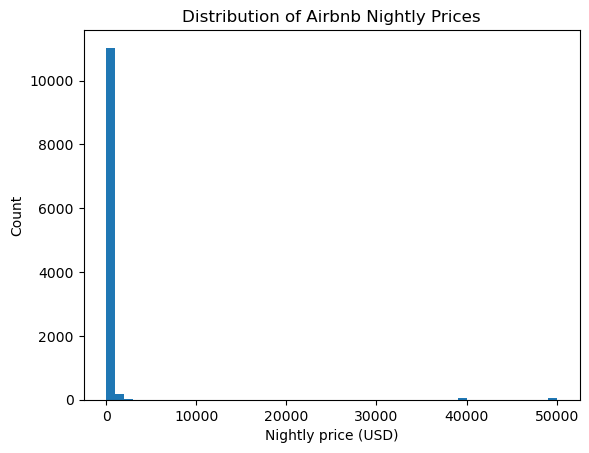

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# clean nightly_price -> numeric
price_num = (
    listings["price"]
    .astype(str)
    .str.replace(r"[\$,]", "", regex=True)
)
price_num = pd.to_numeric(price_num, errors="coerce")

plt.hist(price_num.dropna(), bins=50)
plt.title("Distribution of Airbnb Nightly Prices")
plt.xlabel("Nightly price (USD)")
plt.ylabel("Count")
plt.show()

In [8]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

import sys
sys.path.append('./modules')
import os

# Check if data already exists
if os.path.exists('data/00-raw/listings.csv'):
    print("Data already exists, skipping download.")
else:
    print("listings.csv not found in data/00-raw/. Please add it manually.")

Data already exists, skipping download.


### Dataset #1 

Instructions: 
1. Change the header from Dataset #1 to something more descriptive of the dataset
2. Write a few paragraphs about this dataset. Make sure to cover
   1. Describe the important metrics, what units they are in, and giv some sense of what they mean.  For example "Fasting blood glucose in units of mg glucose per deciliter of blood.  Normal values for healthy individuals range from 70 to 100 mg/dL.  Values 100-125 are prediabetic and values >125mg/dL indicate diabetes. Values <70 indicate hypoglycemia. Fasting idicates the patient hasn't eaten in the last 8 hours.  If blood glucose is >250 or <50 at any time (regardless of the time of last meal) the patient's life may be in immediate danger"
   2. If there are any major concerns with the dataset, describe them. For example "Dataset is composed of people who are serious enough about eating healthy that they voluntarily downloaded an app dedicated to tracking their eating patterns. This sample is likely biased because of that self-selection. These people own smartphones and may be healthier and may have more disposable income than the average person.  Those who voluntarily log conscientiously and for long amounts of time are also likely even more interested in health than those who download the app and only log a bit before getting tired of it"
3. Use the cell below to 
    1. load the dataset 
    2. make the dataset tidy or demonstrate that it was already tidy
    3. demonstrate the size of the dataset
    4. find out how much data is missing, where its missing, and if its missing at random or seems to have any systematic relationships in its missingness
    5. find and flag any outliers or suspicious entries
    6. clean the data or demonstrate that it was already clean.  You may choose how to deal with missingness (dropna of fillna... how='any' or 'all') and you should justify your choice in some way
    7. You will load raw data from `data/00-raw/`, you will (optionally) write intermediate stages of your work to `data/01-interim` and you will write the final fully wrangled version of your data to `data/02-processed`
4. Optionally you can also show some summary statistics for variables that you think are important to the project
5. Feel free to add more cells here if that's helpful for you


# Data Wrangling – Airbnb Listings (San Diego 2025)

This section focuses on cleaning and preparing the Airbnb dataset for modeling. We restrict our analysis to the following variables:

**Target variable:**
- `nightly_price` (USD per night)

**Predictor variables:**
- `accommodates`
- `zipcode`
- `property_type`
- `minimum_nights`
- `maximum_nights`
- `amenities`

We clean missing values, remove outliers, standardize data types, and verify that the dataset is suitable for statistical modeling.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the SAME dataset as your wrangling section uses (76-column file)
listings = pd.read_csv("data/00-raw/listings.csv", low_memory=False)
print(listings.columns.tolist()) 

# Keep only columns that actually exist in THIS file
cols_wanted = [
    "nightly_price",
    "room_type",
    "neighbourhood",
    "zipcode",
    "latitude",
    "longitude",
    "accommodates",
    "property_type",
    "minimum_nights",
    "maximum_nights",
    "number_of_reviews",
    "review_scores_rating",
    "amenities",
    "last_review",
]
cols_keep = [c for c in cols_wanted if c in listings.columns]
df = listings[cols_keep].copy()

df.shape, df.columns
print(df.columns.tolist())

['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']
['room_type', 'neighbourhood', 'latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'last_review']


In [10]:
if 'price' in listings.columns:
    df = listings.copy()
    df['nightly_price'] = (
        df['price'].astype(str)
        .str.replace(r'[\$,]', '', regex=True)
    )
    df['nightly_price'] = pd.to_numeric(df['nightly_price'], errors='coerce')
    df = df.dropna(subset=['nightly_price'])
    df = df[df['nightly_price'] > 0]
else:
    raise KeyError("No price column found in CSV. Check your column names with listings.columns")

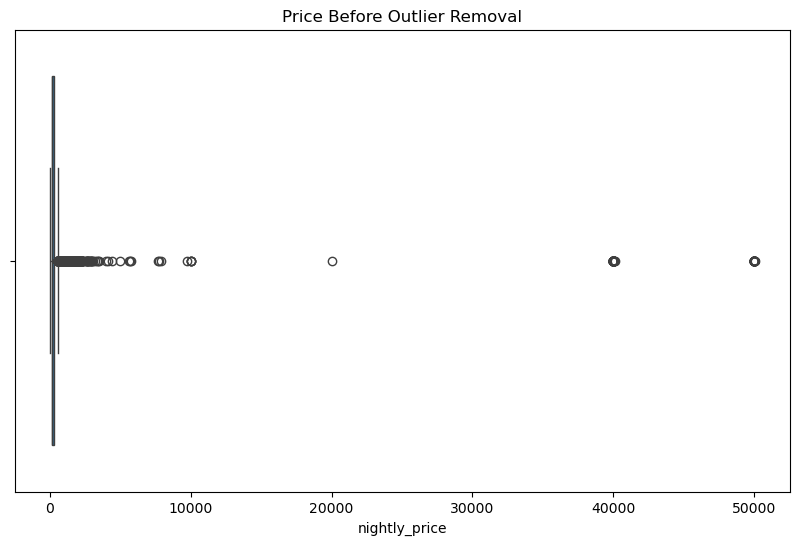

In [11]:
if 'nightly_price' in df.columns:
    plt.figure(figsize=(10,6))
    sns.boxplot(x=df['nightly_price'])
    plt.title("Price Before Outlier Removal")
    plt.show()
else:
    print("nightly_price column does not exist. Cannot plot.")

In [12]:
Q1 = df['nightly_price'].quantile(0.25)
Q3 = df['nightly_price'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

print("Upper bound:", upper_bound)
print("Note: Lower bound not applied since prices cannot be negative.")

df = df[df['nightly_price'] <= upper_bound]

print("After removal:", df.shape)

Upper bound: 577.5
Note: Lower bound not applied since prices cannot be negative.
After removal: (10386, 19)


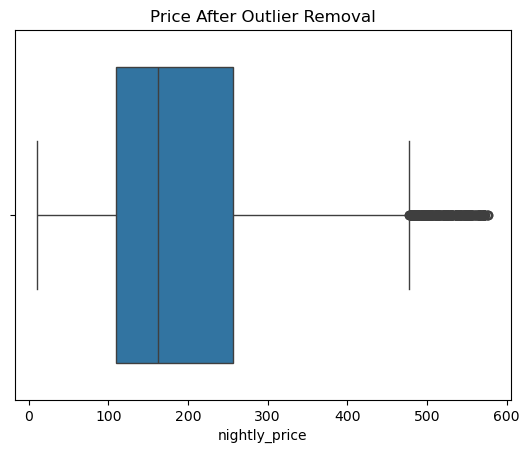

In [13]:
plt.figure()
sns.boxplot(x=df['nightly_price'])
plt.title("Price After Outlier Removal")
plt.show()

In [14]:
#the amenities column (Wi-Fi, pool etc.)
amenity_list = ['Wifi', 'Pool', 'Parking', 'Kitchen', 'Air conditioning']

if 'amenities' in df.columns:
    for amenity in amenity_list:
        col_name = amenity.lower().replace(' ', '_')
        df[col_name] = df['amenities'].str.contains(amenity, case=False, na=False).astype(int)

    print(df[['wifi', 'pool', 'parking', 'kitchen', 'air_conditioning']].sum())
    print("\nSample amenities column:")
    print(df['amenities'].head(3))
else:
    print("No 'amenities' column in this CSV. Skipping amenities processing.")
    print(df.columns.tolist())

No 'amenities' column in this CSV. Skipping amenities processing.
['id', 'name', 'host_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license', 'nightly_price']


In [15]:
import os
os.makedirs("data/02-processed", exist_ok=True)

df.to_csv("data/02-processed/listings_clean.csv", index=False)

### Dataset #2 

### Dataset Description

This dataset comes from the U.S. Census Bureau's American Community Survey (ACS), Table S1901 (Income in the Past 12 Months).

We extract the median household income for San Diego County, California.

- Source: U.S. Census Bureau, ACS 1-Year Estimates (2024)
- Geographic level: County
- Variable used: Median household income (dollars)
- Column: Households!!Estimate

This dataset provides socioeconomic context that may help explain variation in Airbnb nightly prices across regions.

In [16]:
import pandas as pd

census_file = "data/00-raw/ACSST1Y2024.S1901-2026-03-03T062754.csv"
census_raw = pd.read_csv(census_file, low_memory=False)

# Print all column names
print("Columns in CSV:")
print(census_raw.columns.tolist())

# Look at the first 5 rows to understand the structure
print("\nFirst 5 rows:")
print(census_raw.head())

Columns in CSV:
['Label (Grouping)', 'United States!!Households!!Estimate', 'United States!!Households!!Margin of Error', 'United States!!Families!!Estimate', 'United States!!Families!!Margin of Error', 'United States!!Married-couple families!!Estimate', 'United States!!Married-couple families!!Margin of Error', 'United States!!Nonfamily households!!Estimate', 'United States!!Nonfamily households!!Margin of Error']

First 5 rows:
         Label (Grouping) United States!!Households!!Estimate  \
0                   Total                         132,737,146   
1       Less than $10,000                                5.1%   
2      $10,000 to $14,999                                3.3%   
3      $15,000 to $24,999                                6.0%   
4      $25,000 to $34,999                                6.3%   

  United States!!Households!!Margin of Error  \
0                                   ±140,273   
1                                       ±0.1   
2                              

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [17]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [18]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics


Our ethics discussion from the proposal stage remains relevant, and we extend it here with observations grounded in the actual data we have wrangled and explored.

### Data collection and representation bias

The Inside Airbnb dataset captures only listings that were *active and publicly visible* on Airbnb at the time of scraping. This creates a systematic **survivorship bias**: listings that have been deactivated, suspended, or voluntarily removed are not present in our data. Hosts who have exited the platform — potentially due to low demand, poor reviews, or local regulation — are invisible to our analysis. Our findings therefore describe the characteristics of *currently active* listings, not the full universe of San Diego short-term rentals.

Additionally, the geographic distribution of listings in our dataset is uneven. Coastal neighborhoods (La Jolla, Pacific Beach, Mission Beach, Coronado) are heavily represented, while inland and lower-income neighborhoods have comparatively fewer listings. This means our model's performance and interpretations may generalize less well to underrepresented areas of the city.

### Neighbourhood as a proxy variable

One of our core predictors — neighbourhood or ZIP code — is a geographic variable that, in the context of San Diego, carries substantial demographic and socioeconomic meaning. Neighbourhoods in San Diego correlate with race and income due to historical patterns of residential segregation and redlining. When our model uses neighbourhood as a predictor of price, it is not capturing "location" in a purely physical sense; it is also encoding information about the social composition of the area.

We do not claim that our model discriminates by race or income — we have no such variables in our dataset. But we acknowledge that neighbourhood-based price predictions could, in practice, function as proxies for protected attributes. Any downstream use of our model (e.g., to guide pricing decisions) should account for this limitation explicitly.

### Review score bias

Our EDA includes review scores as a predictor variable. Review scores are generated only by guests who have booked and chosen to leave a review, which is a non-random subset of all guests. Guests who had very negative experiences may be less likely to write a review (preferring to simply not return), or conversely, more likely to write a negative one. This uncertainty means that review scores are not a neutral measure of quality — they reflect the opinions of a self-selected subset of guests, mediated by price expectations.

### Platform-level bias

Airbnb's search algorithm, pricing suggestions, and promotional features are not neutral. Listings that appear higher in search results may command higher prices not because of their intrinsic characteristics, but because of platform-mediated visibility advantages. Our dataset does not include information about listing visibility or algorithmic promotion, so we cannot account for this source of variation. Our findings should be understood as describing associations within the platform-visible listing pool, not as capturing the full causal structure of Airbnb pricing.

### Honest representation and scope of conclusions

Throughout our EDA and modeling, we commit to representing our findings honestly. Specifically:

- We do not make causal claims. All associations reported are correlational, derived from observational cross-sectional data.
- We acknowledge that our cleaned dataset excludes extreme outliers, which means our model may not generalize well to very high-end luxury listings or unusually cheap listings.
- We use median rather than mean prices where distributions are skewed, to avoid misleading readers about typical price levels.
- Our results describe pricing patterns on the Airbnb platform in San Diego as of the data collection date. They do not represent the full short-term or long-term rental market.
```



## Team Expectations 

The team expectations established in the proposal remain in effect with specific enhancements to support our workflow-based (rather than module-based) EDA approach.

Communication: Our primary mode of communication remains WeChat for daily updates and Zoom/In-person for weekly syncs. We expect all members to respond within 24 hours. During the EDA phase, "tagging" the next person in the workflow (e.g., Qifeng tagging Alina once data is cleaned) is required to maintain momentum.

Tone & Culture: We continue our "blunt but polite" feedback loop. Given that one person's analysis (e.g., visualization) will now be interpreted by another (e.g., narrative), we commit to open dialogue regarding how data is presented to ensure the "story" told in the text accurately reflects the "data" shown in the plots.

Decision Making: Major project decisions (e.g., dropping a variable, changing a model) require a majority vote. For EDA, the Project Lead (Jing) has final say on the overall narrative structure to ensure rubric alignment.

Task Assignment & Accountability: Tasks are assigned by EDA workflow stages (Wrangling -> Visualization -> Statistical Analysis -> Interpretation) and tracked via GitHub Issues. We have transitioned to this model to prevent unequal workload and ensure "Excellent" ratings for team participation. If a member cannot meet a deadline, they must notify the group 48 hours in advance.

Collaboration Structure (New): We explicitly agree that "the person who codes is not the sole person who writes." For every EDA section, the lead analyst must sync with the interpretation lead (Alina) to ensure the narrative provides the depth required by the COGS 108 rubric.

Conflict Resolution: We assume positive intent and use private "neutral ground" discussions for conflicts. Consistent failure to meet expectations will lead to written notice and, if unresolved after one week, contact with the instructor.

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them
| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| week2-Jan15  |  1 PM | Everyone:Read & Think about COGS 108 expectations; brainstorm topics/questions <br> Jing: Draft initial project topic and research question.| Determine best form of communication; Discuss and decide on final project topic; discuss hypothesis; begin background research | 
| week3-Jan22  |  10 AM |  Everyone: Do background research on topic <br>Jing: Draft Background & Prior Work (2-3 paragraphs). <br>Qifeng: Describe ideal Data (variables like price, location, room type). <br>Alina: Draft Ethics & Privacy + Team Expectations. | Discuss ideal dataset(s) and ethics; draft project proposal; Assign group members to lead each specific part | 
| week5-Feb3  | 10 PM  | Everyone: Edit, finalize, Final proofreading and submit proposal; Search for datasets<br>Yuqian: Write Analysis Plan (Regression/EDA focus).<br>Jing: Merge all sections into the final notebook; Check against rubric. | Submit Proposal. Discuss specific data acquisition strategy for San Diego Airbnb (Inside Airbnb/Kaggle). Wrangling and possible analytical approaches;   |
| week6-Feb11  | 6 PM  | Qifeng: Download and document the SD Airbnb dataset.<br>Ivy: Perform initial Data Cleaning (handling missing prices, filtering SD coordinates).<br>Yuqian: Preliminary EDA on price distribution. | Review Wrangling/EDA: Discuss if we need more features (e.g., amenities, proximity to coast) to test the hypothesis.   |
| week7-Feb18  | 12 PM  | Ivy: Finalize EDA visualizations (Price vs. Location heatmaps).<br>Yuqian: Run initial Regression Models (Price ~ Distance to coast + Room type).<br>Jing: Draft Checkpoint #1 documentation.; submit Checkpoint #1: Data* | Submit Checkpoint #1. Discuss if the model results support the hypothesis that scenic areas = higher prices. |
| week8-Feb28  | 2 PM | Alina: Prepare draft for data bias & ethics interpretation. <br>Yuqian: Complete bivariate analysis (Price vs. Features). | Alina & Yuqian Meeting: Discuss EDA logic flow; align statistical findings with contextual interpretation; identify any bias in the processed data. |
| week9-Mar3  | 12 PM  | Yuqian: Finalize Modeling & Interpretation of results.<br>Alina: Write Discussion (limitations of observational data) & Conclusion.<br>Ivy: Optimize all charts for clarity.<br>Jing: Compile the full project notebook.| Full Project Review: Edit the narrative flow; Ensure ethics/limitations are thoroughly addressed. Submit Checkpoint #2. |
| week10-Mar11  | Before 11:59 PM  | Alina: Finalize Video script & narration coordination.<br>Jing: Final check on all rubric requirements and formatting.<br>Everyone: Complete peer evaluation surveys. | Final Submission: Turn in the Final Project, Video, and Group Surveys. |